In [489]:
import math
import cv2
import numpy as np
import gymnasium as gym

from time import sleep
from gymnasium import spaces
from collections import Counter

from typing import Dict, Any, Sequence, Tuple, Optional

from importnb import Notebook
with Notebook():
    from LabTrajectory import simulate_viewport_with_tiles, visualize_trajectory_sequence

import sys
sys.path.append(r'c:\Users\es25591\Workspace\CacheVideoPredict360\Sources')

from Model.TileIndexer import TileIndexer
from Common.Utils import zipf

In [490]:
def previousTilePrefetcher(step, i, users_viewport_tiles, n) -> np.ndarray:
    step -= 1

    action = np.zeros(n*n, dtype=int)
    
    if step < 0: return action
    
    for tile in users_viewport_tiles[i][step]:
        tx, ty = tile[0], tile[1]
        if 0 > tx or tx >= n or 0 > ty or ty >= n:
            continue
        action[tx * n + ty] = 1
    return action

In [491]:
# ---------- Helper functions implementing formulas from the paper ----------
def compute_td_u(
    B_pu: float, 
    gamma_pu: float
) -> float:
    """
    TD,U = 1 / (Bp,u * log2(1 + gamma_pu))
    B_pu: bandwidth (bytes/sec) for DU p to user u (or effective bandwidth)
    gamma_pu: average SNR
    returns average latency (seconds) per byte
    """
    # prevent division by zero or log2(1+gamma)=0
    denom = B_pu * np.log2(1.0 + max(gamma_pu, 1e-12))
    if denom <= 0:
        return np.inf
    return 1.0 / denom

def compute_tm_u(
    td_u: float, 
    R_M_D: float, 
    U: int
) -> float:
    """
    TM,U = TD,U + 1 / (R_M,D / U) = TD,U + U / R_M,D
    R_M_D: total data rate from MEC to DU (bytes/sec)
    U: number of users sharing link equally
    returns average latency (seconds) per byte
    """
    if R_M_D <= 0 or U <= 0:
        return np.inf
    return td_u + (U / R_M_D)

def compute_tc_u(
    tm_u: float, 
    R_C_M: float, 
    U: int
) -> float:
    """
    TC,U = TM,U + 1 / (R_C,M / U) = TM,U + U / R_C,M
    R_C_M: total data rate from Cloud to MEC (bytes/sec)
    """
    if R_C_M <= 0 or U <= 0:
        return np.inf
    return tm_u + (U / R_C_M)

def compute_ttc(
    rhoT_p: Sequence[float],
    lambda_p: Sequence[float],
    eta: float,
    mu: float
) -> float:
    """
    Ttc = (sum_p rhoT_p * lambda_p / eta) / (mu - sum_p lambda_p)
    Conditions: mu - sum(lambda_p) > 0
    rhoT_p, lambda_p arrays must be same length P
    eta: average data size of computation tasks (bytes)
    mu: service rate of MEC server (bytes/sec of processing capacity)
    returns avg computation latency per byte (seconds/byte)
    """
    rhoT_p = np.asarray(rhoT_p, dtype=float)
    lambda_p = np.asarray(lambda_p, dtype=float)
    if eta <= 0:
        raise ValueError("eta must be > 0")
    denom = mu - np.sum(lambda_p)
    if denom <= 0:
        return np.inf
    numerator = np.sum(rhoT_p * lambda_p / eta)
    return numerator / denom

In [492]:
class LatencyModel:
    """
    LatencyModel computes per-tile latency and total latency for requests
    using the formulas from the paper (TD,U, TM,U, TC,U, Ttc and D matrix).

    P: number of DUs (p in paper)
    U: number of users
    R_M_D: total MEC->DU data rate (bytes/sec)
    R_C_M: total Cloud->MEC data rate (bytes/sec)
    mu: MEC service rate (bytes/sec) for transcoding
    eta: average computation task size (bytes)
    B_pu_matrix: shape (P, U) bandwidths from DU p to user u (bytes/sec). If None, set to 1e6
    gamma_pu_matrix: shape (P, U) SNRs. If None, set to 10 (10 linear)
    rhoT_p: length P list of proportion of transcoding tasks requested at CU
    lambda_p: length P list of arrival rates (requests/sec) from each DU
    """
    def __init__(
        self,
        P: int,
        U: int,
        R_M_D: float,
        R_C_M: float,
        mu: float,
        eta: float,
        B_pu_matrix: np.ndarray,
        gamma_pu_matrix: np.ndarray,
        rhoT_p: Sequence[float],
        lambda_p: Sequence[float],
        du_fixed_delay: float,
        mec_fixed_delay: float,
        cloud_fixed_delay: float
    ):
        self.P = P
        self.U = U
        self.R_M_D = float(R_M_D)
        self.R_C_M = float(R_C_M)
        self.mu = float(mu)
        self.eta = float(eta)

        self.du_fixed_delay = float(du_fixed_delay)
        self.mec_fixed_delay = float(mec_fixed_delay)
        self.cloud_fixed_delay = float(cloud_fixed_delay)

        self.B_pu = np.asarray(B_pu_matrix, dtype=float).reshape(P, U)
        self.gamma_pu = np.asarray(gamma_pu_matrix, dtype=float).reshape(P, U)
        self.rhoT_p = np.asarray(rhoT_p, dtype=float)
        self.lambda_p = np.asarray(lambda_p, dtype=float)

        # precompute TD,U
        self.TD_U = np.zeros((P, U), dtype=float)
        for p in range(P):
            for u in range(U):
                self.TD_U[p, u] = compute_td_u(
                    self.B_pu[p, u], 
                    self.gamma_pu[p, u]
                )

    def time_vector(self, p: int, u: int) -> Tuple[float, float, float, float, float]:
        td_u = self.TD_U[p, u]
        tm_u = compute_tm_u(td_u, self.R_M_D, self.U)
        tc_u = compute_tc_u(tm_u, self.R_C_M, self.U)
        ttc = compute_ttc(self.rhoT_p, self.lambda_p, self.eta, self.mu)
        
        return td_u, tm_u, tc_u, tm_u + ttc, tm_u + ttc

    def tile_latency(
        self, 
        p: int, 
        u: int, 
        tile_size_bytes: float, 
        events: Dict[str, int]
    ) -> float:
        """
        events dict must contain binary flags for:
         - 'alpha_p_u', 'alpha_M_u', 'alpha_C_u', 'beta_p_u', 'beta_M_u'
        Order corresponds to the 5 columns in the paper's D matrix.
        Returns latency in seconds for that tile (per tile_size_bytes).
        """
        T_vec = np.array(
            self.time_vector(p, u), 
            dtype=float
        )
        ES_vec = np.array([
            events.get("alpha_p_u", 0),
            events.get("alpha_M_u", 0),
            events.get("alpha_C_u", 0),
            events.get("beta_p_u", 0),
            events.get("beta_M_u", 0),
        ], dtype=float)
        
        per_byte_latency = float(np.dot(ES_vec, T_vec) * tile_size_bytes)

        # add fixed propagation delay(s) - only once per tile when DU or MEC are involved
        fixed = 0.0
        # if served from DU (column alpha_p_u) -> add DU fixed delay
        if events.get("alpha_p_u", 0) == 1 or events.get("beta_p_u", 0) == 1:
            fixed += self.du_fixed_delay
        # if served via MEC (alpha_M_u or beta_M_u) -> add MEC fixed delay
        if events.get("alpha_M_u", 0) == 1 or events.get("beta_M_u", 0) == 1:
            fixed += self.mec_fixed_delay
        # alpha_C_u (cloud) may also include additional fixed delays you can add as needed
        if events.get("alpha_C_u", 0) == 1:
            fixed += self.cloud_fixed_delay

        return per_byte_latency + fixed

    def total_request_latency(
        self, 
        p: int, 
        u: int, 
        tiles: Sequence[Dict[str, Any]]
    ) -> Tuple[float, Sequence[Tuple[str, float]]]:
      
        sorted_tiles = sorted(tiles, key=lambda t: t.get("layer", 0))
        
        total, tile_latencies = 0.0, []
        for tile in sorted_tiles:
            sz     = float(tile["size"])
            events = tile.get("events", {})
            tid    = tile.get("tile", None)
            layer  = tile.get("layer", 0)

            lat = self.tile_latency(p, u, sz, events)
            tile_latencies.append((tid, layer, lat))

            if total + lat >= 1.0:
                break
            
            total += lat
            
        return total, tile_latencies

    def compute_latency_for_request(self, request) -> Dict[str, Any]:
        p = request.get("du_id", 0)
        u = request.get("user_id", 0)
        tiles = request.get("tiles", [])

        total_latency, tile_latencies = self.total_request_latency(
            p, 
            u, 
            tiles
        )
        
        return {
            "total_latency": total_latency,
            "tile_latencies": tile_latencies
        }
    
    def user_link_throughput(
        self, 
        p: int, 
        u: int
    ) -> Dict[str, float]:
        """
        Returns per-user throughput (bytes/sec) for each stage:
        - 'du': wireless DU->user
        - 'mec': DU->user + MEC->DU (shared)
        - 'cloud': DU->user + MEC->DU + Cloud->MEC (shared)
        """
        td_u = self.TD_U[p, u]                         # sec/byte
        tm_u = compute_tm_u(td_u, self.R_M_D, self.U)  # sec/byte
        tc_u = compute_tc_u(tm_u, self.R_C_M, self.U)  # sec/byte

        def inv(x): return 0.0 if not np.isfinite(x) or x <= 0 else (1.0 / x)

        return {
            "du": inv(td_u),        # bytes/sec over DU->user link
            "mec": inv(tm_u),       # bytes/sec including MEC->DU
            "cloud": inv(tc_u)      # bytes/sec including Cloud->MEC
        }

    def request_effective_throughput(
        self, 
        p: int, 
        u: int, 
        tiles: Sequence[Dict[str, Any]]
    ) -> float:
        """
        Effective throughput for a request = total_bytes / total_time.
        Uses tile_latency() to accumulate time over all tiles.
        """
        total_bytes = 0.0
        total_time = 0.0
        for tile in tiles:
            sz = float(tile["size"])
            events = tile.get("events", {})
            total_bytes += sz
            total_time += self.tile_latency(p, u, sz, events)
        
        if total_time <= 0 or not np.isfinite(total_time):
            return 0.0
        
        return total_bytes / total_time

In [493]:
class UserTileRequestEvents:
    def __init__(
        self,
        n: int = 4,
        n_users: int = 1,
        n_layers: int = 1,
        n_tiles: int = 4,
        users_viewport_tiles: Optional[Sequence[Any]] = [],
        requested_videos: Optional[Sequence[Any]] = []
    ):
        self.n = n
        self.step_count = 0
        self.n_users = n_users
        self.n_layers = n_layers
        self.n_tiles = n_tiles
        self.users_viewed_tiles = users_viewport_tiles
        self.videos_requests = requested_videos
    
    def get_request_for_user(
        self, 
        step: int, 
        u_id: int, 
        p_id: int,
        by_video
    ) -> Dict[str, Any]:
        # For demonstration, return a fixed request structure
        video = self.videos_requests[u_id]
        tiles = []

        # Create base layer tiles (all tiles in the grid)
        size_bytes = (2 * 10e6) / self.n_tiles
        for y_idx in range(self.n):
            for x_idx in range(self.n):
                tile = {
                    "tile": y_idx * self.n + x_idx,
                    "layer": 0,
                    "size": size_bytes,
                    "events": {
                        "alpha_p_u": 1 if by_video[video][0][y_idx * self.n + x_idx] > 0 else 0, 
                        "alpha_M_u": 0, 
                        "alpha_C_u": 0 if by_video[video][0][y_idx * self.n + x_idx] > 0 else 1, 
                        "beta_p_u": 0, 
                        "beta_M_u": 0   
                    }
                }
                tiles.append(tile)
            
        size_bytes = (15 * 10e6) / self.n_tiles
        for x, y in self.users_viewed_tiles[u_id][step]:
            if x < 0 or x >= self.n or y < 0 or y >= self.n:
                continue

            tile = {
                "tile": y * self.n + x,
                "layer": 1,
                "size": size_bytes,
                "events": {
                    "alpha_p_u": 1 if by_video[video][1][y * self.n + x] > 0 else 0, 
                    "alpha_M_u": 0, 
                    "alpha_C_u": 0 if by_video[video][1][y * self.n + x] > 0 else 1, 
                    "beta_p_u": 0, 
                    "beta_M_u": 0
                }
            }
            tiles.append(tile)
        
        return {
            "seq": step,
            "u": u_id,
            "p": p_id, 
            "video": video,
            "tiles": tiles
        }

    def step(self, by_video):
        p = 0  # assuming DU id 0 for simplicity
        reqs = [
            self.get_request_for_user(self.step_count, i, p, by_video)
            for i in range(self.n_users)
        ]

        self.step_count += 1
        return reqs

    def reset(self, **kwargs):
        return np.array([0.0]), {}

In [494]:
class PrefetchingCacheEnv:
    def __init__(
        self, 
        n_tiles: int = 16,
        n_layers: int = 2,
        n_videos: int = 100,
        n_users: int = 10,
        cache_capacity: float = 100e6,  # capacity in bytes
    ):
        self.cur_capacity = 0
        self.max_capacity = cache_capacity
        self.tile_size_bytes = {
            0: 2 * 10e6 / n_tiles,   # base layer tile size in bytes
            1: 15 * 10e6 / n_tiles   # enhancement layer tile size in bytes
        }
        self.n_layers = n_layers
        self.n_videos = n_videos
        self.n_tiles = n_tiles
        
        # Cache index matrix: Video x Layers x Tiles
        self.cache_matrix = np.zeros((n_videos, n_layers, n_tiles), dtype=np.int8)


    def cache_tile(self, vid, layer, tile_idx): 
        tile_size = self.tile_size_bytes[layer]
        
        if self.cur_capacity + tile_size <= self.max_capacity:
            self.cur_capacity += tile_size
            self.cache_matrix[vid, layer, tile_idx] = 1
            return True
        
        return False

    def step(self, action):
        """
        Cache tiles layer-by-layer: base layer first (all tiles), then enhancement layers (viewport tiles only).
        Priority: video popularity for base layer, request count for enhancement layers.
        """
        self.cache_matrix.fill(0)
        self.cur_capacity = 0.0

        # Cache base layer tiles based on video popularity
        video_counts = Counter(user_action.get('video') for user_action in action)
        for v, _ in video_counts.most_common():
            for t in range(self.n_tiles):
                if not self.cache_tile(v, 0, t):
                    break

        # Cache enhancement layer tiles based on user requests
        enh_tile_counts = Counter()
        for user_action in action:
            v = user_action.get('video')
            tiles = user_action.get('tiles', [])
            for i, tile in enumerate(tiles):
                if tile == 0:
                    continue
                enh_tile_counts[(v, i)] += 1
                
        for (v, t), _ in enh_tile_counts.most_common():
            if not self.cache_tile(v, 1, t):
                break

        return self.get_cache_matrix()
    
    def get_cache_matrix(self):
        """Returns the current cache matrix (Video x Layers x Tiles)"""
        return self.cache_matrix.copy()

In [495]:
class EnvWrapper(gym.Env):
    """
    Simple wrapper that delegates all calls to an inner env.
    Subclass this to create your own wrappers.
    """

    def __init__(
        self, 
        n: int,
        n_layers: int,
        users_env: None,
        cache_env: None,
        latency_model: LatencyModel, 
        fetch_request_callable=None
    ):
        super().__init__()

        self.n = n  # number of tiles per row/column
        self.n_layers = n_layers  # number of layers (base + enhancement)
        
        self.gain_if_prefetched = 1.0
        self.loss_if_not_prefetched = -1.0

        self.theta = 0.5
        self.lam = 3.7183

        self.users_env = users_env
        self.cache_env = cache_env
        self.latency_model = latency_model
        self.fetch_request_callable = fetch_request_callable

    def step(self, action):
        reward = 0.0
        info = {}

        ### STEP 1: prefetching segments in the cache based on action taken by agent ###
        by_video = self.cache_env.step(action)

        # print("Complete cache matrix by_video:")
        # print(f"Shape: {by_video.shape}")
        # for vid_idx in range(by_video.shape[0]):
        #     print(f"\nVideo {vid_idx}:")
        #     for layer_idx in range(by_video.shape[1]):
        #         print(f"  Layer {layer_idx}: {by_video[vid_idx, layer_idx]}")

        ### STEP 2: Generate user requests ###
        reqs = self.users_env.step(by_video)
        # print("User requests:", reqs)

        ### STEP 3: compute latencies for each request ###
        total_latency = 0.0
        for req in reqs:
            p = req.get("p", 0)
            u = req.get("u", 0)
            tiles = req.get("tiles", [])
            
            req_latency, tile_latencies = self.latency_model.total_request_latency(
                p, 
                u, 
                tiles
            )
            
            total_latency += req_latency
            # print(
            #     f"User {u}, DU {p}, total latency: {req_latency:.4f}s, tiles requested: {len(tiles)}, tiles received: {len(tile_latencies)}"
            # )            
        
        ### STEP 4: Calculate metrics: cache hits and misses, and reward ###
        cache_hits = 0
        cache_misses = 0
        for req in reqs:
            vid = req['video']
            tiles = req['tiles']
            # print(f"Request for video {vid} with tiles: {tiles}")

            for tile in tiles:
                tile_idx = tile['tile']
                layer = tile['layer']

                if by_video[vid][layer][tile_idx] >= 1:
                    cache_hits += 1
                else:
                    cache_misses += 1

        info['cache_hits'] = int(cache_hits)
        info['cache_misses'] = int(cache_misses)

        # compute reward for this video's action and add
        total_requests = sum(len(req.get('tiles', [])) for req in reqs)
        
        # Compute current_p: probability for each (vid, tile_idx) based on requests
        tile_counts = {}
        for req in reqs:
            vid = req["video"]
            tiles = req["tiles"]
            for tile in tiles:
                key = (vid, tile['layer'], tile['tile'])
                tile_counts[key] = tile_counts.get(key, 0) + 1

        # Normalize by total_requests to get probabilities
        current_p = {
            key: count / total_requests
            for key, count in tile_counts.items()
        }
    
        reward += self.compute_expected_cpt_reward(
            prefetched_tiles=by_video,
            current_p=current_p,
            requests=reqs
        )

        return {}, reward, False, info

    def compute_expected_cpt_reward(self, prefetched_tiles, current_p, requests) -> float:
        expected_reward = 0.0
        requested_tile_keys = set()
        for request in requests:
            vid = request['video']
            tiles = request['tiles']

            for tile in tiles:
                layer = tile['layer']
                tile_idx = tile['tile']
                tile_key = (vid, layer, tile_idx)
                
                p = float(current_p.get(tile_key, 0.0))
                w = self.prelec_w(p, theta=self.theta)
                
                if prefetched_tiles[vid][layer][tile_idx] >= 1:
                    expected_outcome = self.gain_if_prefetched
                    requested_tile_keys.add(tile_key)
                else:
                    expected_outcome = self.loss_if_not_prefetched
                
                v = self.cpt_value(expected_outcome, lam=self.lam)
                expected_reward += w * v

        return float(expected_reward)

    def prelec_w(self, p: float, theta: float = 0.65) -> float:
        if p <= 0.0: return 0.0
        if p >= 1.0: return 1.0
        return math.exp(-((-math.log(p)) ** theta))

    def cpt_value(
        self,
        x: float, 
        lam: float = 1.5
    ) -> float:
        if x >= 0:
            return x
        else:
            return -lam * (-x)

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

    def render(self, mode="human"):
        return self.env.render(mode)

In [496]:
if __name__ == "__main__":
    n_episodes = 500
    n_steps = 60
    total_videos = 100
    n_gops = 60
    n_users = 30
    n_tiles = 4
    n_layers = 2
    max_capacity = 50e6  # 50 MB

    users_viewport_tiles = []
    for f in range(n_users):
        yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
            num_steps=n_gops,
            n=n_tiles,
            fov_yaw=90,
            fov_pitch=50,
            damping=0.99,
            step_size=5.0,
            start_yaw=180,
            start_pitch=0
        )

        users_viewport_tiles.append(tiles_per_frame)
    
    requested_videos = zipf(n_users, total_videos=total_videos, alpha=1.0)
    requested_videos = [int(v-1) for v in requested_videos]

    users_env = UserTileRequestEvents(
        n_users=n_users,
        n_tiles=n_tiles*n_tiles,
        n_layers=n_layers,
        users_viewport_tiles=users_viewport_tiles,
        requested_videos=requested_videos
    )

    cache_env = PrefetchingCacheEnv(
        n_tiles=n_tiles*n_tiles,
        n_videos=total_videos,
        cache_capacity=max_capacity,
    )

    # Create latency model (replace numbers with your real config)
    P = 1; U = n_users
    lat_model = LatencyModel(
        P=P, 
        U=U,
        R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, U), 40e6, dtype=float),       # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, U), 5.0, dtype=float),    # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    env = EnvWrapper(
        n=n_tiles,
        n_layers=n_layers,
        users_env=users_env, 
        cache_env=cache_env, 
        latency_model=lat_model
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Videos requested: {requested_videos}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {total_videos}x{n_layers}x{n_tiles*n_tiles}\n"
        f"==============================\n"
    )

    total_reward = 0.0
    for step in range(n_steps):
        actions = [
            {
                'user': i,
                'video': requested_videos[i],
                'tiles': previousTilePrefetcher(step, i, users_viewport_tiles, n_tiles)
            } for i in range(n_users)
        ]

        obs, reward, _, info = env.step(actions)

        total_reward += float(reward)

Experiment ===================
Total users: 30
Videos requested: [26, 26, 74, 52, 74, 47, 49, 26, 85, 85, 26, 52, 26, 89, 93, 70, 26, 74, 21, 86, 26, 26, 10, 74, 6, 74, 44, 26, 81, 26]
Cache capacity: 50000000.0MB
Video matrix: 100x2x16



In [497]:
def run_episodes(
    n_episodes,
    n_steps,
    total_videos,
    max_capacity, 
    step_size,
    n_gops,
    n_layers,
    n_users,
    n
):
    episode_rewards = []
    episode_lengths = []
    episode_cache_hits = []
    episode_cache_misses = []

    for ep in range(n_episodes):

        users_viewport_tiles = []
        for f in range(n_users):
            yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
                num_steps=n_gops,
                n=n,
                fov_yaw=90,
                fov_pitch=50,
                damping=0.99,
                step_size=step_size,
                start_yaw=180,
                start_pitch=0
            )

            users_viewport_tiles.append(tiles_per_frame)
        
        requested_videos = zipf(n_users, total_videos=total_videos, alpha=1.0)
        requested_videos = [int(v-1) for v in requested_videos]

        users_env = UserTileRequestEvents(
            n_users=n_users,
            n_tiles=n*n,
            n_layers=n_layers,
            users_viewport_tiles=users_viewport_tiles,
            requested_videos=requested_videos
        )

        cache_env = PrefetchingCacheEnv(
            n_tiles=n*n,
            n_videos=total_videos,
            cache_capacity=max_capacity,
        )

        # Create latency model (replace numbers with your real config)
        P = 1; U = n_users
        lat_model = LatencyModel(
            P=P, 
            U=U,
            R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
            R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
            mu=2e7, 
            eta=2e5,
            B_pu_matrix=np.full((P, U), 40e6, dtype=float),       # 320 Mbps -> 40e6 B/s
            gamma_pu_matrix=np.full((P, U), 5.0, dtype=float),    # SNRs
            rhoT_p=[0.2], 
            lambda_p=[0.05],
            du_fixed_delay=0.001,    # 1 ms
            mec_fixed_delay=0.005,   # 5 ms
            cloud_fixed_delay=0.05   # 50 ms
        )

        env = EnvWrapper(
            n=n,
            n_layers=n_layers,
            users_env=users_env, 
            cache_env=cache_env, 
            latency_model=lat_model
        )

        total_reward = 0.0
        cache_hits = 0
        cache_misses = 0
    
        for step in range(n_steps):
            actions = [
                {
                    'user': i,
                    'video': requested_videos[i],
                    'tiles': previousTilePrefetcher(step, i, users_viewport_tiles, n)
                } for i in range(n_users)
            ]

            _, reward, _, info = env.step(actions)
            total_reward += float(reward)

            cache_hits += info.get('cache_hits', 0)
            cache_misses += info.get('cache_misses', 0)

        episode_lengths.append(n_steps)
        episode_rewards.append(total_reward)

        episode_cache_hits.append(int(cache_hits))
        episode_cache_misses.append(int(cache_misses))

    stats = {
        "n_episodes": n_episodes,
        "mean_steps": float(np.mean(episode_lengths)),
        "std_steps": float(np.std(episode_lengths)),
        "mean_reward": float(np.mean(episode_rewards)),
        "std_reward": float(np.std(episode_rewards)),
        "episode_lengths": episode_lengths,
        "episode_rewards": episode_rewards,
        "mean_cache_hits": float(np.mean(episode_cache_hits)),
        "std_cache_hits": float(np.std(episode_cache_hits)),
        "mean_cache_misses": float(np.mean(episode_cache_misses)),
        "std_cache_misses": float(np.std(episode_cache_misses)),
    }

    return stats

Total Videos: 100, Capacity: 10000000.0, Mean reward: -10897.8322, Std reward: 328.7383
Total Videos: 100, Capacity: 20000000.0, Mean reward: -9374.5527, Std reward: 754.3433
Total Videos: 100, Capacity: 20000000.0, Mean reward: -9374.5527, Std reward: 754.3433
Total Videos: 100, Capacity: 30000000.0, Mean reward: -8490.0635, Std reward: 707.6313
Total Videos: 100, Capacity: 30000000.0, Mean reward: -8490.0635, Std reward: 707.6313
Total Videos: 100, Capacity: 40000000.0, Mean reward: -7779.9276, Std reward: 838.8580
Total Videos: 100, Capacity: 40000000.0, Mean reward: -7779.9276, Std reward: 838.8580
Total Videos: 100, Capacity: 50000000.0, Mean reward: -6928.6432, Std reward: 897.0192
Total Videos: 100, Capacity: 50000000.0, Mean reward: -6928.6432, Std reward: 897.0192
Total Videos: 100, Capacity: 60000000.0, Mean reward: -6451.4249, Std reward: 851.0915
Total Videos: 100, Capacity: 60000000.0, Mean reward: -6451.4249, Std reward: 851.0915
Total Videos: 100, Capacity: 70000000.0, M

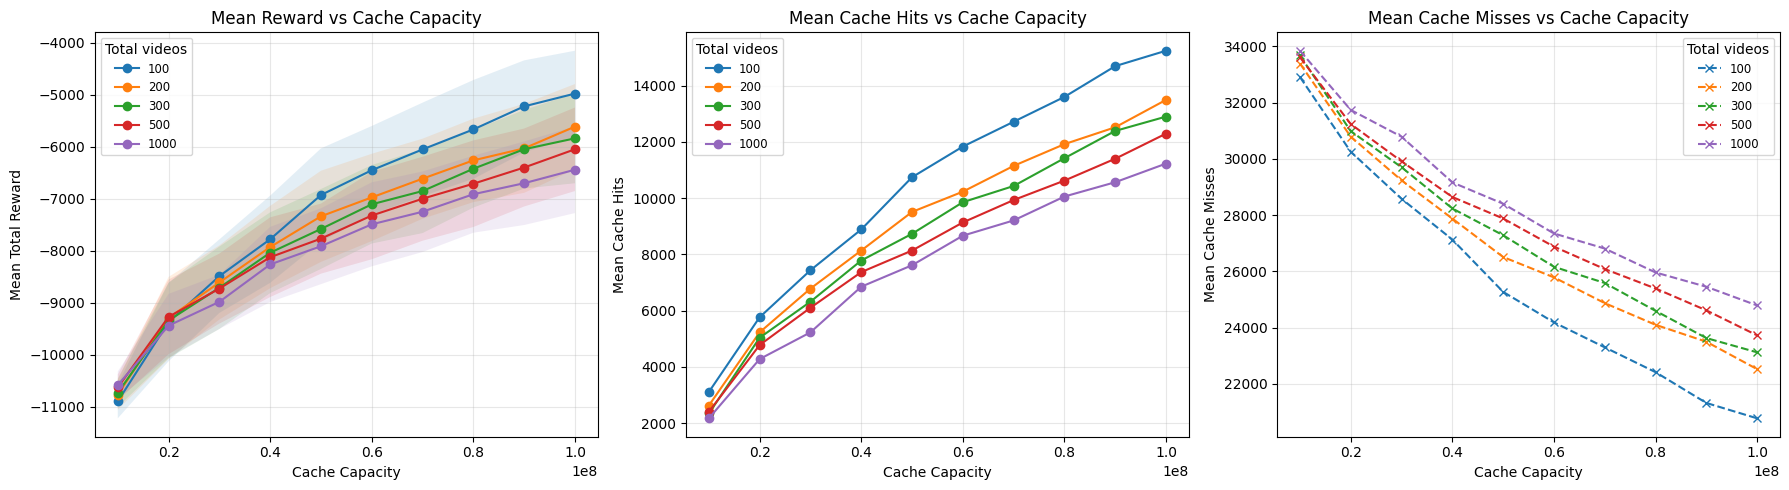

In [498]:
if __name__ == '__main__':
    capacities = [10e6, 20e6, 30e6, 40e6, 50e6, 60e6, 70e6, 80e6, 90e6, 100e6]
    total_videos_list = [100, 200, 300, 500, 1000]

    n_episodes = 100
    n_steps = 60
    n_users = 30
    step_size = 1.5
    n_gops = 60
    n_layers = 2
    n_tiles = 4
    
    # Store results for each total_videos
    results_by_videos = {}

    for total_videos in total_videos_list:
        capacity_results = {}
        for i, capacity in enumerate(capacities):

            results = run_episodes(
                n_episodes=n_episodes,
                n_steps=n_steps,
                total_videos=total_videos,
                max_capacity=capacity,
                step_size=step_size,
                n_gops=n_gops,
                n_layers=n_layers,
                n_users=n_users,
                n=n_tiles
            )

            capacity_results[capacity] = results

            print(
                f"Total Videos: {total_videos}, Capacity: {capacity}, "
                f"Mean reward: {results['mean_reward']:.4f}, "
                f"Std reward: {results['std_reward']:.4f}"
            )

        # Store results for this total_videos
        results_by_videos[total_videos] = capacity_results

    # Plot the results
    import matplotlib.pyplot as plt
    caps = capacities

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    ax_reward, ax_hits, ax_misses = axes

    # Reward (mean ± std as shaded band)
    for total_videos in total_videos_list:
        means = [results_by_videos[total_videos][c]['mean_reward'] for c in caps]
        stds  = [results_by_videos[total_videos][c]['std_reward']  for c in caps]
        ax_reward.plot(caps, means, marker='o', label=f'{total_videos}')
        ax_reward.fill_between(caps,
                               np.array(means) - np.array(stds),
                               np.array(means) + np.array(stds),
                               alpha=0.12)
    ax_reward.set_xlabel('Cache Capacity')
    ax_reward.set_ylabel('Mean Total Reward')
    ax_reward.set_title('Mean Reward vs Cache Capacity')
    ax_reward.grid(alpha=0.3)
    ax_reward.legend(title='Total videos', fontsize='small')

    # Cache hits
    for total_videos in total_videos_list:
        cache_hits = [results_by_videos[total_videos][c]['mean_cache_hits'] for c in caps]
        ax_hits.plot(caps, cache_hits, marker='o', label=f'{total_videos}')
    ax_hits.set_xlabel('Cache Capacity')
    ax_hits.set_ylabel('Mean Cache Hits')
    ax_hits.set_title('Mean Cache Hits vs Cache Capacity')
    ax_hits.grid(alpha=0.3)
    ax_hits.legend(title='Total videos', fontsize='small')

    # Cache misses
    for total_videos in total_videos_list:
        cache_misses = [results_by_videos[total_videos][c]['mean_cache_misses'] for c in caps]
        ax_misses.plot(caps, cache_misses, marker='x', linestyle='--', label=f'{total_videos}')
    ax_misses.set_xlabel('Cache Capacity')
    ax_misses.set_ylabel('Mean Cache Misses')
    ax_misses.set_title('Mean Cache Misses vs Cache Capacity')
    ax_misses.grid(alpha=0.3)
    ax_misses.legend(title='Total videos', fontsize='small')

    plt.tight_layout()
    plt.show()